> **Chapter 15, Part 4** | Engineering lens. **Focus:** parse the repo's real dbt models into an asset graph automatically, the same way Dagster's dbt integration does.

# Wrapping the Repo's dbt Project as Assets

Chapter 9 of this repo ships a dbt project at `dbt/dbt_dq`. Its models reference each other with `ref('model_name')`. Those `ref()` calls *are* the dependency edges, which means we can build an asset graph from the SQL without running dbt at all. This is exactly what Dagster's `dagster-dbt` integration does: it reads the dbt manifest and turns each model into a software-defined asset.

We do the lightweight version: a regex over the `.sql` files. If the dbt directory is not present (someone copied just this folder), we fall back to embedded sample SQL with the same shape, so the notebook always runs.

In [1]:
# The tiny orchestrator we build across 15.1-15.3, collected into one cell.
from collections import deque
from dataclasses import dataclass
from typing import Callable, Optional


@dataclass
class Asset:
    name: str
    deps: list
    compute: Callable
    partitioned: bool = False


class AssetGraph:
    def __init__(self):
        self.assets = {}

    def add(self, asset):
        self.assets[asset.name] = asset
        return self

    def _downstream(self):
        down = {n: [] for n in self.assets}
        for n, a in self.assets.items():
            for d in a.deps:
                if d in down:
                    down[d].append(n)
        return down

    def topological_order(self):
        indeg = {n: 0 for n in self.assets}
        for n, a in self.assets.items():
            for d in a.deps:
                if d in indeg:
                    indeg[n] += 1
        down = self._downstream()
        q = deque(sorted(n for n, k in indeg.items() if k == 0))
        order = []
        while q:
            n = q.popleft()
            order.append(n)
            for m in sorted(down[n]):
                indeg[m] -= 1
                if indeg[m] == 0:
                    q.append(m)
        if len(order) != len(self.assets):
            stuck = sorted(n for n in self.assets if n not in order)
            raise ValueError("cycle detected among assets: " + ", ".join(stuck))
        return order

    def _needed(self, targets):
        need = set()
        stack = list(targets)
        while stack:
            n = stack.pop()
            if n in need or n not in self.assets:   # ignore refs outside the graph
                continue
            need.add(n)
            stack.extend(self.assets[n].deps)
        return need

    def materialize(self, targets=None, log=None, partition=None, verbose=True):
        order = self.topological_order()
        if targets is not None:
            need = self._needed(targets)
            order = [n for n in order if n in need]
        results = {}
        for n in order:
            tag = " [" + str(partition) + "]" if partition is not None else ""
            if log is not None and log.is_materialized(n, partition):
                results[n] = log.value(n, partition)
                if verbose:
                    print("  skip   " + n + tag + " (already materialized)")
                continue
            inputs = {d: results.get(d) for d in self.assets[n].deps}
            value = self.assets[n].compute(inputs)
            results[n] = value
            if log is not None:
                log.record(n, partition, value)
            if verbose:
                print("  build  " + n + tag)
        return results


class MaterializationLog:
    def __init__(self):
        self.store = {}

    def is_materialized(self, name, partition=None):
        return (name, partition) in self.store

    def record(self, name, partition=None, value=None):
        self.store[(name, partition)] = value

    def value(self, name, partition=None):
        return self.store[(name, partition)]


def backfill(graph, target, partitions, log, verbose=True):
    report = {"materialized": [], "skipped": []}
    order = [n for n in graph.topological_order() if n in graph._needed([target])]
    for p in partitions:
        for n in order:
            if log.is_materialized(n, p):
                report["skipped"].append((n, p))
                continue
            inputs = {d: (log.value(d, p) if log.is_materialized(d, p) else None)
                      for d in graph.assets[n].deps}
            log.record(n, p, graph.assets[n].compute(inputs))
            report["materialized"].append((n, p))
    return report


def blast_radius(graph, failed):
    down = graph._downstream()
    seen, stack = set(), list(down[failed])
    while stack:
        n = stack.pop()
        if n in seen:
            continue
        seen.add(n)
        stack.extend(down[n])
    return seen


@dataclass
class RetryPolicy:
    max_attempts: int = 1


def materialize_with_failures(graph, failing=None, retry=None, verbose=True):
    failing = failing or {}
    retry = retry or RetryPolicy()
    order = graph.topological_order()
    status, results, attempts_used = {}, {}, {}
    for n in order:
        if any(status.get(d) in ("failed", "skipped") for d in graph.assets[n].deps):
            status[n] = "skipped"
            if verbose:
                print("  skip    " + n + " (upstream failed)")
            continue
        attempts, ok = 0, False
        while attempts < retry.max_attempts:
            attempts += 1
            if attempts <= failing.get(n, 0):
                if verbose:
                    print("  retry   " + n + " attempt " + str(attempts) + " failed")
                continue
            ok = True
            break
        attempts_used[n] = attempts
        if ok:
            inputs = {d: results.get(d) for d in graph.assets[n].deps}
            results[n] = graph.assets[n].compute(inputs)
            status[n] = "materialized"
            if verbose:
                print("  build   " + n + " (attempt " + str(attempts) + ")")
        else:
            status[n] = "failed"
            if verbose:
                print("  FAIL    " + n + " (exhausted " + str(retry.max_attempts) + " attempts)")
    return status, results, attempts_used


print("orchestrator core ready:", len([Asset, AssetGraph, MaterializationLog,
      backfill, blast_radius, RetryPolicy, materialize_with_failures]), "building blocks")

orchestrator core ready: 7 building blocks


In [2]:
import re
from pathlib import Path

# Walk up from the notebook to find dbt/dbt_dq/models. Fall back to embedded SQL.
here = Path.cwd()
models_dir = None
for base in [here, *here.parents]:
    candidate = base / "dbt" / "dbt_dq" / "models"
    if candidate.exists():
        models_dir = candidate
        break

sources = {}
if models_dir is not None:
    for sql in sorted(models_dir.glob("*.sql")):
        sources[sql.stem] = sql.read_text(encoding="utf-8")
    print(f"read {len(sources)} dbt models from {models_dir}")
else:
    # Fallback: the same shape as the repo's models.
    sources = {
        "calendar": "select 1 as date_key",
        "stg_nyc_taxi": "select * from {{ ref('nyc_taxi_data') }}",
        "nyc_taxi_data": "select 1 as trip_id",
        "nyc_taxi_transform": ("select t.*, c.date_key "
                               "from {{ ref('stg_nyc_taxi') }} t "
                               "cross join {{ ref('calendar') }} c"),
    }
    print("dbt project not found; using embedded sample SQL")

print("models:", ", ".join(sorted(sources)))

read 4 dbt models from /Users/haridines/github/personal/python_training/dbt/dbt_dq/models
models: calendar, nyc_taxi_data, nyc_taxi_transform, stg_nyc_taxi


## From `ref()` calls to edges

A dbt `ref('x')` inside model `y` means `y` depends on `x`. One regex extracts every edge. The result is a real dependency graph for the repo's own data-quality models.

In [3]:
REF = re.compile(r"ref\(\s*['\"]([A-Za-z0-9_]+)['\"]\s*\)")

dbt_graph = AssetGraph()
for model, sql in sources.items():
    deps = list(dict.fromkeys(REF.findall(sql)))      # dedupe, preserve order
    dbt_graph.add(Asset(model, deps, (lambda i: {"ok": True})))

# Some refs point at seeds (taxi_zone_lookup) that are not model files.
# Add them as source assets so the graph is complete and safe to traverse.
known = set(dbt_graph.assets)
for model in list(dbt_graph.assets):
    for dep in dbt_graph.assets[model].deps:
        if dep not in known:
            dbt_graph.add(Asset(dep, [], (lambda i: {"seed": True})))
            known.add(dep)

for model in sorted(dbt_graph.assets):
    deps = dbt_graph.assets[model].deps
    print(f"{model:22s} <- {', '.join(deps) if deps else '(source)'}")

print()
print("safe build order:", " -> ".join(dbt_graph.topological_order()))

calendar               <- (source)
nyc_taxi_data          <- (source)
nyc_taxi_transform     <- nyc_taxi_data, taxi_zone_lookup, calendar
stg_nyc_taxi           <- nyc_taxi_data
taxi_zone_lookup       <- (source)

safe build order: calendar -> nyc_taxi_data -> taxi_zone_lookup -> stg_nyc_taxi -> nyc_taxi_transform


Materializing this graph is `dbt build` in dependency order, minus the warehouse. Each asset's compute would run the model's SQL; here it just returns a marker so the notebook stays offline.

In [4]:
print("materialize the dbt asset graph (offline stand-in for `dbt build`):")
dbt_graph.materialize()

materialize the dbt asset graph (offline stand-in for `dbt build`):
  build  calendar
  build  nyc_taxi_data
  build  taxi_zone_lookup
  build  stg_nyc_taxi
  build  nyc_taxi_transform


{'calendar': {'ok': True},
 'nyc_taxi_data': {'ok': True},
 'taxi_zone_lookup': {'seed': True},
 'stg_nyc_taxi': {'ok': True},
 'nyc_taxi_transform': {'ok': True}}

## Draw the dbt lineage

This is the Chapter 12 lineage graph, except every node is a dbt model the repo actually ships, and the edges came from parsing SQL. Orchestration and lineage are the same DAG seen from two angles: lineage asks "what feeds what", orchestration asks "in what order do I build it".

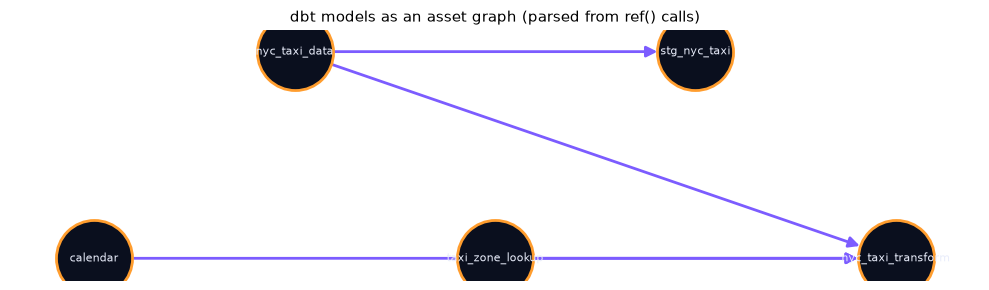

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for n, a in dbt_graph.assets.items():
    G.add_node(n)
    for d in a.deps:
        if d in dbt_graph.assets:
            G.add_edge(d, n)

order = dbt_graph.topological_order()
pos = {n: (order.index(n), (order.index(n) % 2) * 0.5 - 0.25) for n in G.nodes}

fig, ax = plt.subplots(figsize=(10, 3))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#7c5cff", width=2, arrowsize=16, node_size=3000)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#0a0f1e", edgecolors="#ff9d2e",
                       linewidths=2, node_size=3000)
nx.draw_networkx_labels(G, pos, ax=ax, font_color="#e9edfb", font_size=8)
ax.set_title("dbt models as an asset graph (parsed from ref() calls)", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

In production you would not regex the SQL; you would read `target/manifest.json` after `dbt parse`, which gives you the exact compiled DAG plus column-level lineage. The one-liner for that path:

```bash
dbt ls --output json   # or: dbt parse && read target/manifest.json
```

The principle is identical. dbt already knows its graph; an orchestrator's job is to read that graph and materialize it on a schedule, with partitions, sensors, and retries layered on. Next: what happens when one of these models fails.